In [2]:
import os
from glob import glob
import matplotlib.pyplot as plt
import pickle
import pandas as pd
import numpy as np
from collections import OrderedDict

from spectral.io import envi

from isofit.core.fileio import IO
from isofit.core.forward import ForwardModel
from isofit.inversion.inverse import Inversion
from isofit.inversion.inverse_simple import invert_algebraic, invert_analytical
from isofit.configs import configs
from isofit.core.geometry import Geometry
import logging

# Enable the ISOFIT logger
logging.getLogger().setLevel(logging.INFO)

os.chdir('/store/carroll/col/data/2018/')

%matplotlib widget

In [16]:
# load all relevant data

base_dir_reference = 'rccs/cal_tarp'
base_dir_test = 'rccs/bright_dark'

rccs_raw = np.loadtxt('rccs/rcc_white_tarp_mean_20250829.txt')
rccs_detrended = np.loadtxt('rccs/rcc_white_tarp_mean_postprocess_detrended_20250903_wholeswir2.txt')

# isofit dirs
reference_flights = [x for x in os.listdir(base_dir_reference) if x.startswith('NIS')]
reference_flights = ['_'.join(x.split('_')[:3]) for x in reference_flights]
test_flights = [x for x in os.listdir(base_dir_test) if x.startswith('NIS')]

# reference targets (calibration tarps)
with open('rccs/cal_tarp/single_pxs.pkl', 'rb') as f:
    reference_px = pickle.load(f)
    
# bright, dark targets visually selected from multiple flightlines
with open('rccs/bright_dark/single_pxs.pkl', 'rb') as f:
    bright_dark_px = pickle.load(f)

# prep wavelengths
wl = np.loadtxt('/store/carroll/col/data/wavelengths_neon.txt')[:,1]*1000
wl_nan = np.loadtxt('/store/carroll/col/data/wl_nan.txt')

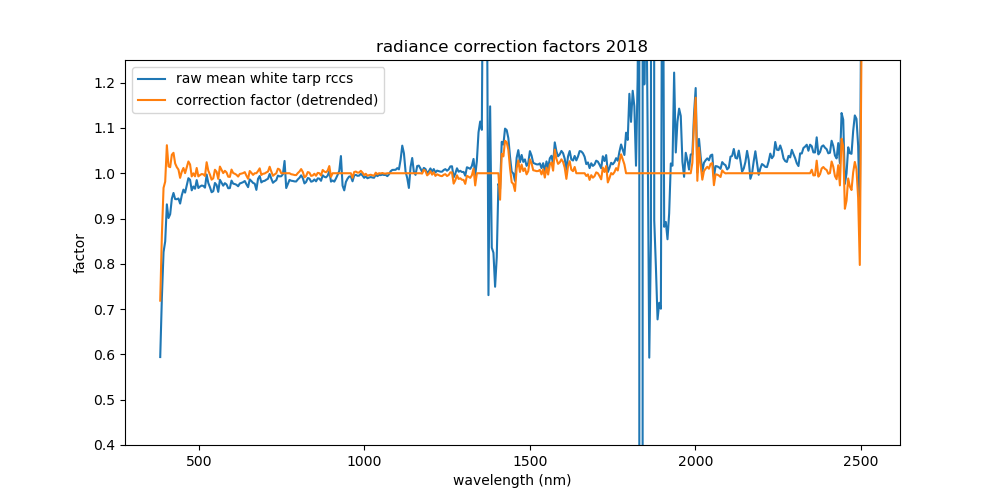

In [21]:
# viz rccs

fig = plt.figure(figsize=(10,5))

plt.plot(wl, rccs_raw, label='raw mean white tarp rccs')
plt.plot(wl, rccs_detrended, label='correction factor (detrended)')


plt.xlabel('wavelength (nm)')
plt.ylabel('factor')
plt.ylim(0.4, 1.25)
plt.title('radiance correction factors 2018')
plt.legend()

# plt.savefig(os.path.join(out_figs, 'raw_rccs_2018.png'), dpi=300)

plt.show()

In [20]:
# ignore_zones_conservative = [[0.7457, 0.7755], [0.9024, 0.960], [1.0665, 1.1735], [1.34, 1.410], [1.640,1.670], [1.79, 1.99], # water absorption regions (narrower)
#                 # [[0.7457, 0.7755], [0.9024, 0.960], [1.0665, 1.1735], [1.33, 1.465], [1.77, 2.05], # water absorption regions
#                 [0.669, 0.679],
#                 [2.096, 2.350]] # identified systematics - most conservative
#                # [0.669, 0.679], [2.096, 2.192], [2.231,2.269], [2.306, 2.317], [2.430, 2.460]] # identified systematics - less conservative


# ignore_zones = [[0.7457, 0.7755], [0.9024, 0.960], [1.0665, 1.1735], [1.33, 1.465], [1.77, 2.05], # water absorption regions
#                [0.669, 0.679], [2.096, 2.192], [2.231,2.269], [2.306, 2.317], [2.430, 2.460]] # identified systematics

ignore_zones = [[0.7457, 0.7755], [0.9024, 0.960], [1.0665, 1.1735], [1.34, 1.410], [1.640,1.670], [1.79, 1.99], # water absorption regions (narrower)
                # [[0.7457, 0.7755], [0.9024, 0.960], [1.0665, 1.1735], [1.33, 1.465], [1.77, 2.05], # water absorption regions
                [0.669, 0.679],
                [2.096, 2.350]] # identified systematics - most conservative
               # [0.669, 0.679], [2.096, 2.192], [2.231,2.269], [2.306, 2.317], [2.430, 2.460]] # identified systematics - less conservative

INFO:root:Loading config file: rccs/bright_dark/NIS01_20180612_173258/config/NIS01_20180612_173258_isofit.json
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/radiative_transfer_engine.py:Loading from wavelength_file: /store/carroll/col/data/2018/rccs/bright_dark/NIS01_20180612_173258/data/wavelengths.txt
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/radiative_transfer_engine.py:Prebuilt LUT provided
INFO:isofit.radiative_transfer.luts:Loading LUT into memory
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/radiative_transfer_engine.py:LUT grid loaded from file
INFO:root:Loading config file: rccs/bright_dark/NIS01_20180612_173258/config/NIS01_20180612_173258_isofit.json
INFO:/store/carroll/miniforge3/envs/isofit_env/lib/python3.12/site-packages/isofit/radiative_transfer/radiative_transfer_engine.py:Loading from wavelength_fil

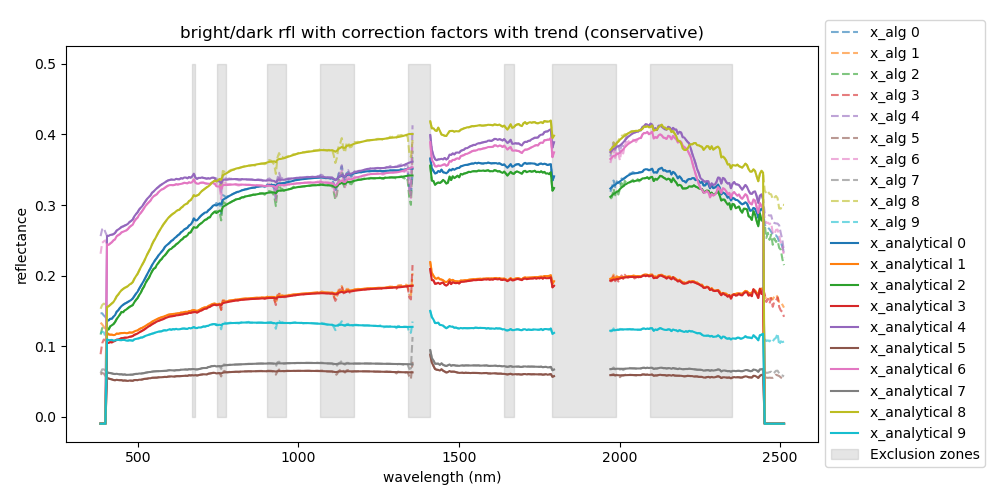

In [25]:
# retrieve rfl w adjusted radiance

rcc = rccs_detrended
izs = ignore_zones

base_dir = base_dir_test

alg_rfl = []
analytical_rfl = []

for flight_id in test_flights:
    for k in ['bright', 'dark']:
        working_dir = glob(os.path.join(base_dir, f'{flight_id}*'))[0]
        
        if base_dir==base_dir_reference:
            rdn = reference_px['rdn'][flight_id][k]
            obs = reference_px['obs'][flight_id][k]
            loc = reference_px['loc'][flight_id][k]
        else:
            rdn = bright_dark_px[flight_id][k]['rdn']
            obs = bright_dark_px[flight_id][k]['obs']
            loc = bright_dark_px[flight_id][k]['loc']
        
        # load config as-is
        fp_config = os.path.join(working_dir, 'config', f'{flight_id}_isofit.json')
        config = configs.create_new_config(fp_config)
        
        # set up forward model, io, inversion according to config
        fm = ForwardModel(config)
        io = IO(config, fm)
        inv = Inversion(config, fm)
        
        # load the isofit geometry representation of the single pixel
        geom = Geometry(obs=obs, loc=loc)
        geom.sky_view_factor = 1 # updated isofit dev 8/20 and now this is necessary? Not sure why skyview factor is no longer automatically populating to 1 when none provided
        
        # adjust rdn
        meas = rdn.copy()
        meas = meas*rcc
        
        # retrieve rfl
        states=inv.invert(meas, geom)
        xa_surface = fm.surface.xa(states[0,...][fm.idx_surface].copy(), geom) # get surface prior mean
        x_surface, x_RT, x_instrument = fm.unpack(states[-1,:])
        x_alg, coeffs = invert_algebraic(fm.surface, fm.RT, fm.instrument, x_surface, x_RT, x_instrument, meas, geom)
        rfl_est = fm.surface.fit_params(x_alg, geom)
        x0 = np.concatenate([rfl_est, x_RT, x_instrument])
        states, unc, EXIT_CODE = invert_analytical(inv.fm, inv.winidx, meas, geom, np.copy(x0), states[-1,:], num_iter = 1, hash_table = OrderedDict(), hash_size = 500)
        out_rfl_est = states[-1, fm.idx_surf_rfl]
        
        alg_rfl.append(x_alg)
        analytical_rfl.append(out_rfl_est)

# viz solutions

fig = plt.figure(figsize=(10,5))

for i in range(len(alg_rfl)):
    plt.plot(wl_nan, alg_rfl[i], label=f'x_alg {i}', alpha=0.6, ls='--')
for i in range(len(alg_rfl)):
    plt.plot(wl_nan, analytical_rfl[i], label=f'x_analytical {i}')

for _el, el in enumerate(izs):
    if _el == 0:
        plt.fill_between(np.array(el)*1000, 0, 0.5, color='grey', alpha=0.2, label='Exclusion zones')
    else:
        plt.fill_between(np.array(el)*1000, 0, 0.5, color='grey', alpha=0.2)
        
plt.ylabel('reflectance')
plt.xlabel('wavelength (nm)')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.title('bright/dark rfl with correction factors with trend (conservative)')
plt.show()

# export the alg (and analytical?) solutions for the blue solution!
fp_out = os.path.join('rccs', 'alg_rfl_blueline_postproces_detrend_20251128.txt')
np.savetxt(fp_out, alg_rfl[9])

fp_out = os.path.join('rccs', 'analytical_rfl_blueline_postproces_detrend_20251128.txt')
np.savetxt(fp_out, analytical_rfl[9])

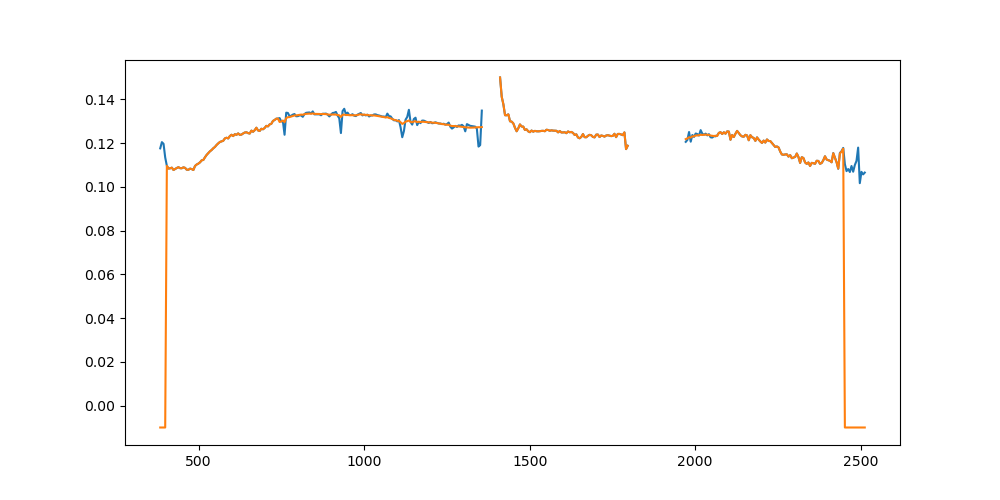

In [27]:
# visual check on the export blue line rfl
fp = os.path.join('rccs', 'alg_rfl_blueline_postproces_detrend_20251128.txt')
alg_rfl = np.loadtxt(fp)

fp = os.path.join('rccs', 'analytical_rfl_blueline_postproces_detrend_20251128.txt')
analytical_rfl = np.loadtxt(fp)

fig = plt.figure(figsize=(10,5))
plt.plot(wl_nan, alg_rfl, label='alg rfl')
plt.plot(wl_nan, analytical_rfl, label='analytical rfl')
plt.show()